In [1]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
tokenizer

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

BertTokenizerFast(name_or_path='bert-base-uncased', vocab_size=30522, model_max_length=512, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)

In [2]:
!wget https://github.com/npradaschnor/Pima-Indians-Diabetes-Dataset/raw/master/diabetes.csv
#!unzip statlog+german+credit+data.zip

--2025-04-20 15:03:37--  https://github.com/npradaschnor/Pima-Indians-Diabetes-Dataset/raw/master/diabetes.csv
Resolving github.com (github.com)... 140.82.116.3
Connecting to github.com (github.com)|140.82.116.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv [following]
--2025-04-20 15:03:37--  https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 23105 (23K) [text/plain]
Saving to: ‘diabetes.csv’

diabetes.csv        100%[===================>]  22.56K  --.-KB/s    in 0.001s  

2025-04-20 15:03:37 (16.9 MB/s) - ‘diabetes.csv’ saved [23105/231

In [3]:
# !unzip census+income.zip

In [4]:
!pip install openml

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.4/160.4 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.1/95.1 kB 6.2 MB/s eta 0:00:00
  Created wheel for liac-arff: filename=liac_arff-2.5.0-py3-none-any.whl size=11716 sha256=09128c3388c060f844b79357b769f93098436561253ea825a7994fbff7284d0a
  Stored in directory: /root/.cache/pip/wheels/5d/2a/9c/3895d9617f8f49a0883ba686326d598e78a1c2f54fe3cae86d
Successfully built liac-arff


In [5]:
import pandas as pd

df = pd.read_csv('diabetes.csv')
print(len(df))
df

768


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [6]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [7]:
import numpy as np
import torch

DROP_P = 0.2

def concatenate_text(x_full):
    x = {}
    for i, j in x_full.items():
        x[i] = j if np.random.random() > DROP_P else '[UNK]'
    
    text = "".join([f"I have information about a woman. ",
            f"She has been pregnant {x['Pregnancies']} times. ",
            f"Her plasma glucose concentration in an oral glucose tolerance test is {x['Glucose']}. ",
            f"Her diastolic blood pressure is {x['BloodPressure']} (mm Hg). ",
            f"Her triceps skin fold thickness is {x['SkinThickness']} (mm). ",
            f"Her 2-Hour serum insulin is {x['Insulin']} (mu U/ml). ",
            f"Her body mass index is {x['BMI']}. ",
            f"Her diabetes pedigree function {x['DiabetesPedigreeFunction']}. ",
            f"Her age is {x['Age']} years old."])

    
    return text

concatenate_text(df.iloc[0])

'I have information about a woman. She has been pregnant 6.0 times. Her plasma glucose concentration in an oral glucose tolerance test is [UNK]. Her diastolic blood pressure is [UNK] (mm Hg). Her triceps skin fold thickness is 35.0 (mm). Her 2-Hour serum insulin is 0.0 (mu U/ml). Her body mass index is 33.6. Her diabetes pedigree function 0.627. Her age is 50.0 years old.'

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df.drop('Outcome', axis =1),
                                                    df['Outcome'],
                                                    test_size=.2,
                                                    random_state = 42)
# y_train = y_train.replace({1:1, 2:0})
# y_test = y_test.replace({1:1, 2:0})

X_train['text'] = X_train.apply(lambda x: concatenate_text(x), axis=1)
X_test['text'] = X_test.apply(lambda x: concatenate_text(x), axis=1)

X_train['label'] = y_train
X_test['label'] = y_test

In [9]:
X_train['text'].iloc[0]

'I have information about a woman. She has been pregnant 2.0 times. Her plasma glucose concentration in an oral glucose tolerance test is 84.0. Her diastolic blood pressure is 0.0 (mm Hg). Her triceps skin fold thickness is [UNK] (mm). Her 2-Hour serum insulin is 0.0 (mu U/ml). Her body mass index is 0.0. Her diabetes pedigree function 0.304. Her age is 21.0 years old.'

In [10]:
len(X_train)

614

In [11]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 2.9 MB/s eta 0:00:00


In [12]:
import torch
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset
import numpy as np
import evaluate

# Define label mappings
# id2label = {0: "NOT-DONATE", 1: "DONATE"}
# label2id = {"NOT-DONATE": 0, "DONATE": 1}

# Convert to Hugging Face Dataset format
train_dataset = Dataset.from_pandas(X_train)
test_dataset = Dataset.from_pandas(X_test)

def tokenize_function(examples):
    # Adjust based on the structure of your dataset
    return tokenizer(examples['text'], padding='max_length', truncation=True, max_length=128)

tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
tokenized_test_dataset = test_dataset.map(tokenize_function, batched=True)

# Format the datasets correctly with labels
tokenized_train_dataset = tokenized_train_dataset.map(lambda x: {'labels': x['label']})
tokenized_test_dataset = tokenized_test_dataset.map(lambda x: {'labels': x['label']})

Map:   0%|          | 0/614 [00:00<?, ? examples/s]

Map:   0%|          | 0/154 [00:00<?, ? examples/s]

Map:   0%|          | 0/614 [00:00<?, ? examples/s]

Map:   0%|          | 0/154 [00:00<?, ? examples/s]

In [13]:
tokenized_train_dataset[0].keys()

dict_keys(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'text', 'label', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask', 'labels'])

In [14]:
tokenized_train_dataset[0]['text']

'I have information about a woman. She has been pregnant 2.0 times. Her plasma glucose concentration in an oral glucose tolerance test is 84.0. Her diastolic blood pressure is 0.0 (mm Hg). Her triceps skin fold thickness is [UNK] (mm). Her 2-Hour serum insulin is 0.0 (mu U/ml). Her body mass index is 0.0. Her diabetes pedigree function 0.304. Her age is 21.0 years old.'

In [15]:
tokenized_train_dataset[0]['label']

0

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Roc Auc
1,0.718000,0.708810,0.490542
2,0.663200,0.652167,0.487236
3,0.649500,0.652474,0.500643
4,0.647600,0.660422,0.505234
5,0.664600,0.654707,0.503949
6,0.645400,0.652111,0.503398
7,0.646700,0.656491,0.501010
8,0.664300,0.658037,0.500092
9,0.649100,0.656610,0.500826
10,0.649100,0.651857,0.498072


{'eval_loss': 0.651856541633606, 'eval_roc_auc': 0.49807162534435256, 'eval_runtime': 0.5979, 'eval_samples_per_second': 257.548, 'eval_steps_per_second': 5.017, 'epoch': 10.0}
test f1 0.0
test precision 0.0
test recall 0.0
test accuracy 0.0
test roc_auc 0.4719926538108356



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


train f1 0.0
train precision 0.0
train recall 0.0
train accuracy 0.6530944625407166
train roc_auc 0.5099223771557023


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


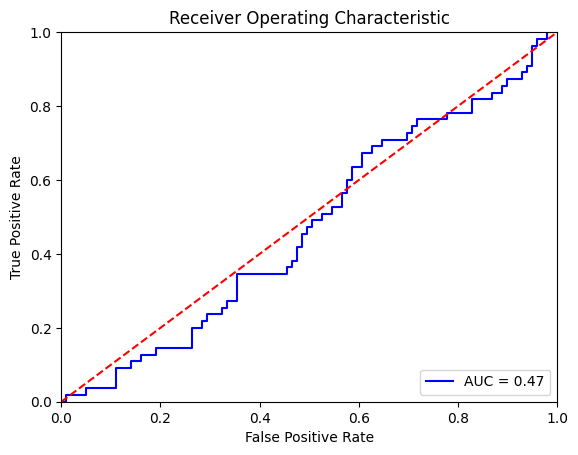

In [16]:
from transformers import BertForSequenceClassification
from transformers import DataCollatorWithPadding
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
from sklearn.metrics import roc_curve, auc
import sklearn.metrics as metrics
import matplotlib.pyplot as plt
import sklearn.metrics as metrics

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2).to('cuda')

model.dropout.p = 0

for param in model.bert.parameters():
    param.requires_grad = False

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=10,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    warmup_steps=0,
    learning_rate = 0.001,
    weight_decay=0.001,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    report_to='none'
)

# Evaluation metric
auc = evaluate.load("roc_auc")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    return auc.compute(prediction_scores=predictions, references=labels)

# Define the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Train the model
trainer.train()

results = trainer.evaluate()
print(results)

pred = trainer.predict(tokenized_test_dataset)
print("test f1", f1_score(y_test, np.argmax(pred[0], 1)))
print("test precision", precision_score(y_test, np.argmax(pred[0], 1)))
print("test recall", recall_score(y_test, np.argmax(pred[0], 1)))
print("test accuracy", precision_score(y_test, np.argmax(pred[0], 1)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

pred_train = trainer.predict(tokenized_train_dataset)
print("train f1", f1_score(y_train, np.argmax(pred_train[0], 1)))
print("train precision", precision_score(y_train, np.argmax(pred_train[0], 1)))
print("train recall", recall_score(y_train, np.argmax(pred_train[0], 1)))
print("train accuracy", accuracy_score(y_train, np.argmax(pred_train[0], 1)))

fpr_train, tpr_train, threshold_train = roc_curve(y_train, pred_train[0][:, 1])
roc_auc_train = metrics.auc(fpr_train, tpr_train)
print("train roc_auc", roc_auc_train)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

Epoch,Training Loss,Validation Loss,Roc Auc
1,0.646800,0.651931,0.517723
2,0.646500,0.651148,0.535170
3,0.643300,0.649835,0.556290
4,0.638000,0.646863,0.573554
5,0.631400,0.642059,0.609734
6,0.601500,0.635587,0.623324
7,0.588700,0.624649,0.628650
8,0.576200,0.620188,0.635078
9,0.573300,0.619657,0.635262
10,0.571800,0.623358,0.639669


{'eval_loss': 0.6233580112457275, 'eval_roc_auc': 0.6396694214876032, 'eval_runtime': 0.6101, 'eval_samples_per_second': 252.397, 'eval_steps_per_second': 4.917, 'epoch': 10.0}
test f1 0.367816091954023
test precision 0.5
test recall 0.2909090909090909
test accuracy 0.5
test roc_auc 0.6460973370064279



train f1 0.48710601719197705
train precision 0.625
train recall 0.39906103286384975
train accuracy 0.7084690553745928
train roc_auc 0.7630922693266833


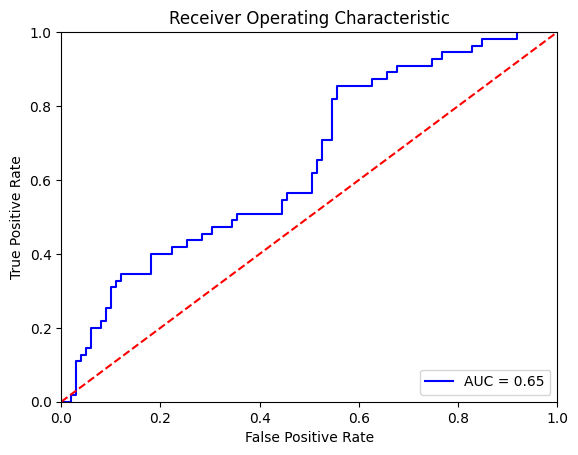

In [17]:
for param in model.bert.parameters():
    param.requires_grad = True

model.dropout.p = 0.0

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=10,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    warmup_steps=0,
    learning_rate = 0.00001,
    weight_decay=0.001,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    report_to='none'
)

# Evaluation metric
auc = evaluate.load("roc_auc")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    return auc.compute(prediction_scores=predictions, references=labels)

# Define the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Train the model
trainer.train()

results = trainer.evaluate()
print(results)

pred = trainer.predict(tokenized_test_dataset)
print("test f1", f1_score(y_test, np.argmax(pred[0], 1)))
print("test precision", precision_score(y_test, np.argmax(pred[0], 1)))
print("test recall", recall_score(y_test, np.argmax(pred[0], 1)))
print("test accuracy", precision_score(y_test, np.argmax(pred[0], 1)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

pred_train = trainer.predict(tokenized_train_dataset)
print("train f1", f1_score(y_train, np.argmax(pred_train[0], 1)))
print("train precision", precision_score(y_train, np.argmax(pred_train[0], 1)))
print("train recall", recall_score(y_train, np.argmax(pred_train[0], 1)))
print("train accuracy", accuracy_score(y_train, np.argmax(pred_train[0], 1)))

fpr_train, tpr_train, threshold_train = roc_curve(y_train, pred_train[0][:, 1])
roc_auc_train = metrics.auc(fpr_train, tpr_train)
print("train roc_auc", roc_auc_train)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

Map:   0%|          | 0/614 [00:00<?, ? examples/s]

Map:   0%|          | 0/154 [00:00<?, ? examples/s]

Map:   0%|          | 0/614 [00:00<?, ? examples/s]

Map:   0%|          | 0/154 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Roc Auc
1,0.666300,0.651365,0.527273
2,0.655400,0.654880,0.528926
3,0.660600,0.671570,0.526722
4,0.659700,0.651444,0.524518
5,0.655800,0.651726,0.528191
6,0.646500,0.651771,0.530028
7,0.648300,0.653840,0.532415
8,0.668400,0.662506,0.534619
9,0.650600,0.660146,0.534803
10,0.651800,0.651898,0.533517


{'eval_loss': 0.651898205280304, 'eval_roc_auc': 0.5335169880624426, 'eval_runtime': 0.6125, 'eval_samples_per_second': 251.421, 'eval_steps_per_second': 4.898, 'epoch': 10.0}
test f1 0.0
test precision 0.0
test recall 0.0
test accuracy 0.0
test roc_auc 0.5270890725436179



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


train f1 0.0
train precision 0.0
train recall 0.0
train accuracy 0.6530944625407166
train roc_auc 0.5004741666959363


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


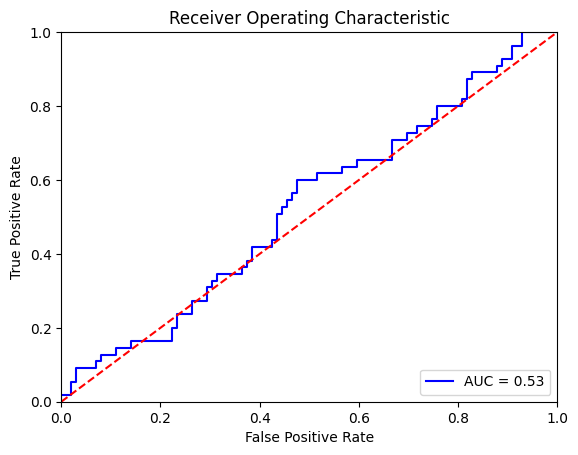

In [18]:
DROP_P = 0.5

X_train, X_test, y_train, y_test = train_test_split(df.drop('Outcome', axis =1),
                                                    df['Outcome'],
                                                    test_size=.2,
                                                    random_state = 42)
# y_train = y_train.replace({1:1, 2:0})
# y_test = y_test.replace({1:1, 2:0})

X_train['text'] = X_train.apply(lambda x: concatenate_text(x), axis=1)
X_test['text'] = X_test.apply(lambda x: concatenate_text(x), axis=1)

X_train['label'] = y_train
X_test['label'] = y_test

train_dataset = Dataset.from_pandas(X_train)
test_dataset = Dataset.from_pandas(X_test)

tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
tokenized_test_dataset = test_dataset.map(tokenize_function, batched=True)

# Format the datasets correctly with labels
tokenized_train_dataset = tokenized_train_dataset.map(lambda x: {'labels': x['label']})
tokenized_test_dataset = tokenized_test_dataset.map(lambda x: {'labels': x['label']})

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2).to('cuda')

model.dropout.p = 0

for param in model.bert.parameters():
    param.requires_grad = False

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=10,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    warmup_steps=0,
    learning_rate = 0.001,
    weight_decay=0.001,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    report_to='none'
)

# Evaluation metric
auc = evaluate.load("roc_auc")

# Define the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Train the model
trainer.train()

results = trainer.evaluate()
print(results)

pred = trainer.predict(tokenized_test_dataset)
print("test f1", f1_score(y_test, np.argmax(pred[0], 1)))
print("test precision", precision_score(y_test, np.argmax(pred[0], 1)))
print("test recall", recall_score(y_test, np.argmax(pred[0], 1)))
print("test accuracy", precision_score(y_test, np.argmax(pred[0], 1)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

pred_train = trainer.predict(tokenized_train_dataset)
print("train f1", f1_score(y_train, np.argmax(pred_train[0], 1)))
print("train precision", precision_score(y_train, np.argmax(pred_train[0], 1)))
print("train recall", recall_score(y_train, np.argmax(pred_train[0], 1)))
print("train accuracy", accuracy_score(y_train, np.argmax(pred_train[0], 1)))

fpr_train, tpr_train, threshold_train = roc_curve(y_train, pred_train[0][:, 1])
roc_auc_train = metrics.auc(fpr_train, tpr_train)
print("train roc_auc", roc_auc_train)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

Epoch,Training Loss,Validation Loss,Roc Auc
1,0.647800,0.650541,0.601102
2,0.646900,0.649031,0.611938
3,0.645300,0.647236,0.620569
4,0.643600,0.642320,0.626814
5,0.641400,0.640381,0.623875
6,0.631100,0.633003,0.633609
7,0.627700,0.630593,0.635445
8,0.627600,0.652149,0.634527
9,0.620500,0.632347,0.629017
10,0.619700,0.631401,0.629568


{'eval_loss': 0.6314013600349426, 'eval_roc_auc': 0.6295684113865933, 'eval_runtime': 0.6123, 'eval_samples_per_second': 251.504, 'eval_steps_per_second': 4.899, 'epoch': 10.0}
test f1 0.0
test precision 0.0
test recall 0.0
test accuracy 0.0
test roc_auc 0.6242424242424243



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


train f1 0.0
train precision 0.0
train recall 0.0
train accuracy 0.6530944625407166
train roc_auc 0.6430285787877725


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


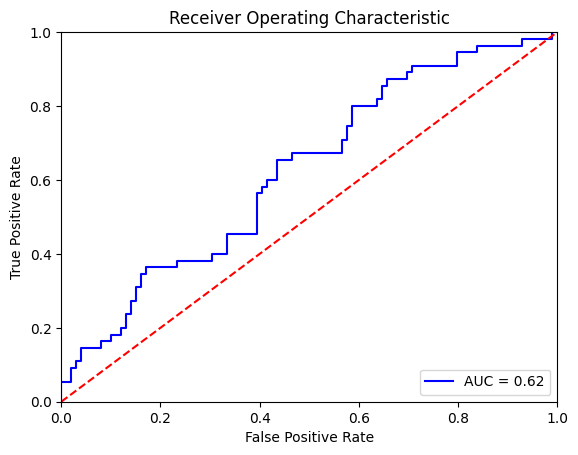

In [19]:
for param in model.bert.parameters():
    param.requires_grad = True

model.dropout.p = 0.0

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=10,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    warmup_steps=0,
    learning_rate = 0.00001,
    weight_decay=0.001,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    report_to='none'
)

# Evaluation metric
auc = evaluate.load("roc_auc")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    return auc.compute(prediction_scores=predictions, references=labels)

# Define the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Train the model
trainer.train()

results = trainer.evaluate()
print(results)

pred = trainer.predict(tokenized_test_dataset)
print("test f1", f1_score(y_test, np.argmax(pred[0], 1)))
print("test precision", precision_score(y_test, np.argmax(pred[0], 1)))
print("test recall", recall_score(y_test, np.argmax(pred[0], 1)))
print("test accuracy", precision_score(y_test, np.argmax(pred[0], 1)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

pred_train = trainer.predict(tokenized_train_dataset)
print("train f1", f1_score(y_train, np.argmax(pred_train[0], 1)))
print("train precision", precision_score(y_train, np.argmax(pred_train[0], 1)))
print("train recall", recall_score(y_train, np.argmax(pred_train[0], 1)))
print("train accuracy", accuracy_score(y_train, np.argmax(pred_train[0], 1)))

fpr_train, tpr_train, threshold_train = roc_curve(y_train, pred_train[0][:, 1])
roc_auc_train = metrics.auc(fpr_train, tpr_train)
print("train roc_auc", roc_auc_train)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

Map:   0%|          | 0/614 [00:00<?, ? examples/s]

Map:   0%|          | 0/154 [00:00<?, ? examples/s]

Map:   0%|          | 0/614 [00:00<?, ? examples/s]

Map:   0%|          | 0/154 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Roc Auc
1,0.667300,0.655726,0.502112
2,0.653900,0.656173,0.501010
3,0.653900,0.652599,0.489440
4,0.648500,0.664002,0.484573
5,0.666800,0.655270,0.491736
6,0.645200,0.651904,0.485216
7,0.645800,0.655823,0.482461
8,0.660200,0.653579,0.485950
9,0.646100,0.653093,0.478145
10,0.647600,0.652033,0.482002


{'eval_loss': 0.6520325541496277, 'eval_roc_auc': 0.4820018365472911, 'eval_runtime': 0.6252, 'eval_samples_per_second': 246.331, 'eval_steps_per_second': 4.799, 'epoch': 10.0}
test f1 0.0
test precision 0.0
test recall 0.0
test accuracy 0.0
test roc_auc 0.5269054178145087



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


train f1 0.0
train precision 0.0
train recall 0.0
train accuracy 0.6530944625407166
train roc_auc 0.4921733225621392


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


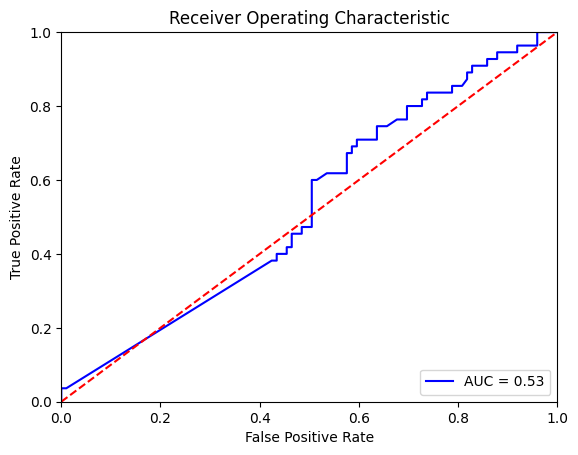

In [20]:
DROP_P = 0.9

X_train, X_test, y_train, y_test = train_test_split(df.drop('Outcome', axis =1),
                                                    df['Outcome'],
                                                    test_size=.2,
                                                    random_state = 42)
# y_train = y_train.replace({1:1, 2:0})
# y_test = y_test.replace({1:1, 2:0})

X_train['text'] = X_train.apply(lambda x: concatenate_text(x), axis=1)
X_test['text'] = X_test.apply(lambda x: concatenate_text(x), axis=1)

X_train['label'] = y_train
X_test['label'] = y_test

train_dataset = Dataset.from_pandas(X_train)
test_dataset = Dataset.from_pandas(X_test)

tokenized_train_dataset = train_dataset.map(tokenize_function, batched=True)
tokenized_test_dataset = test_dataset.map(tokenize_function, batched=True)

# Format the datasets correctly with labels
tokenized_train_dataset = tokenized_train_dataset.map(lambda x: {'labels': x['label']})
tokenized_test_dataset = tokenized_test_dataset.map(lambda x: {'labels': x['label']})

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2).to('cuda')

model.dropout.p = 0

for param in model.bert.parameters():
    param.requires_grad = False

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=10,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    warmup_steps=0,
    learning_rate = 0.001,
    weight_decay=0.001,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    report_to='none'
)

# Evaluation metric
auc = evaluate.load("roc_auc")

# Define the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Train the model
trainer.train()

results = trainer.evaluate()
print(results)

pred = trainer.predict(tokenized_test_dataset)
print("test f1", f1_score(y_test, np.argmax(pred[0], 1)))
print("test precision", precision_score(y_test, np.argmax(pred[0], 1)))
print("test recall", recall_score(y_test, np.argmax(pred[0], 1)))
print("test accuracy", precision_score(y_test, np.argmax(pred[0], 1)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

pred_train = trainer.predict(tokenized_train_dataset)
print("train f1", f1_score(y_train, np.argmax(pred_train[0], 1)))
print("train precision", precision_score(y_train, np.argmax(pred_train[0], 1)))
print("train recall", recall_score(y_train, np.argmax(pred_train[0], 1)))
print("train accuracy", accuracy_score(y_train, np.argmax(pred_train[0], 1)))

fpr_train, tpr_train, threshold_train = roc_curve(y_train, pred_train[0][:, 1])
roc_auc_train = metrics.auc(fpr_train, tpr_train)
print("train roc_auc", roc_auc_train)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

Epoch,Training Loss,Validation Loss,Roc Auc
1,0.648500,0.651248,0.623600
2,0.647300,0.650863,0.570156
3,0.647100,0.651310,0.562718
4,0.646500,0.651199,0.565106
5,0.647100,0.650819,0.567126
6,0.642500,0.651614,0.564371
7,0.644800,0.651163,0.560606
8,0.645200,0.652285,0.569605
9,0.643600,0.650982,0.565473
10,0.645900,0.650721,0.569146


{'eval_loss': 0.6507206559181213, 'eval_roc_auc': 0.5691460055096419, 'eval_runtime': 0.6132, 'eval_samples_per_second': 251.132, 'eval_steps_per_second': 4.892, 'epoch': 10.0}
test f1 0.0
test precision 0.0
test recall 0.0
test accuracy 0.0
test roc_auc 0.5583103764921946



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


train f1 0.0
train precision 0.0
train recall 0.0
train accuracy 0.6530944625407166
train roc_auc 0.5524042007656914


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


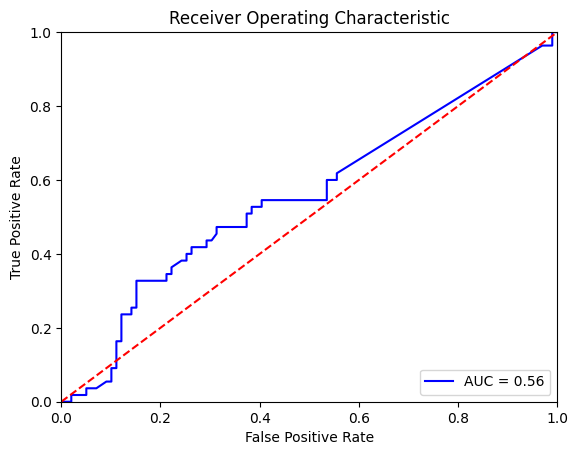

In [21]:
for param in model.bert.parameters():
    param.requires_grad = True

model.dropout.p = 0.0

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=10,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    warmup_steps=0,
    learning_rate = 0.00001,
    weight_decay=0.001,
    logging_dir='./logs',
    logging_steps=10,
    eval_strategy="epoch",
    report_to='none'
)

# Evaluation metric
auc = evaluate.load("roc_auc")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    return auc.compute(prediction_scores=predictions, references=labels)

# Define the trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train_dataset,
    eval_dataset=tokenized_test_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator
)

# Train the model
trainer.train()

results = trainer.evaluate()
print(results)

pred = trainer.predict(tokenized_test_dataset)
print("test f1", f1_score(y_test, np.argmax(pred[0], 1)))
print("test precision", precision_score(y_test, np.argmax(pred[0], 1)))
print("test recall", recall_score(y_test, np.argmax(pred[0], 1)))
print("test accuracy", precision_score(y_test, np.argmax(pred[0], 1)))
fpr, tpr, threshold = roc_curve(y_test, pred[0][:, 1])
roc_auc = metrics.auc(fpr, tpr)
print("test roc_auc", roc_auc)
print("")

pred_train = trainer.predict(tokenized_train_dataset)
print("train f1", f1_score(y_train, np.argmax(pred_train[0], 1)))
print("train precision", precision_score(y_train, np.argmax(pred_train[0], 1)))
print("train recall", recall_score(y_train, np.argmax(pred_train[0], 1)))
print("train accuracy", accuracy_score(y_train, np.argmax(pred_train[0], 1)))

fpr_train, tpr_train, threshold_train = roc_curve(y_train, pred_train[0][:, 1])
roc_auc_train = metrics.auc(fpr_train, tpr_train)
print("train roc_auc", roc_auc_train)


plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()